In [2]:
# Standard library imports
import gc
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import InputLayer, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers, backend as K
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, InputLayer, 
    RandomFlip, Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.applications import  DenseNet121 , ResNet50
from tensorflow.keras.callbacks import EarlyStopping
# Scikit-learn imports
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix


## data preprocessing

In [3]:
# Load the image using PIL
image = Image.open("/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg")
image_array=np.array(image)
image_shape=image_array.shape
print("image shape:",image_shape)

image shape: (1317, 1857)


In [4]:
import os
import random

def count_images_in_directory(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):  # Check if it's a directory
            num_images = len(os.listdir(class_dir))  # Count images in the directory
            class_counts[class_name] = num_images
    return class_counts

def calculate_percentages(counts):
    total_count = sum(counts.values())
    percentages = {class_name: f"{(count / total_count) * 100:.2f}%" for class_name, count in counts.items()}
    return percentages

def create_image_label_file(directory, output_file):
    image_label_pairs = []
    
    # Map class names to labels
    class_to_label = {
        "NORMAL": 0,
        "PNEUMONIA": 1
    }

    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):  # Check if it's a directory
            label = class_to_label.get(class_name.upper())  # Get label for the class name
            if label is not None:  # Proceed if label exists
                for image_name in os.listdir(class_dir):
                    image_path = os.path.join(class_dir, image_name)
                    # Append image path and label to the list
                    image_label_pairs.append(f"{image_path},{label}\n")

    # Shuffle the list of image-label pairs
    random.shuffle(image_label_pairs)

    # Write the shuffled pairs to the output file
    with open(output_file, 'w') as f:
        f.writelines(image_label_pairs)

# Specify your train, val, and test directories
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

# Create text files for train, validation, and test datasets
create_image_label_file(train_dir, 'train_image_labels.txt')
create_image_label_file(val_dir, 'val_image_labels.txt')
create_image_label_file(test_dir, 'test_image_labels.txt')

# Count images in train, validation, and test directories
train_counts = count_images_in_directory(train_dir)
val_counts = count_images_in_directory(val_dir)
test_counts = count_images_in_directory(test_dir)

# Calculate percentages
train_percentages = calculate_percentages(train_counts)
val_percentages = calculate_percentages(val_counts)
test_percentages = calculate_percentages(test_counts)

# Print results
print("*" * 85)
print("Train counts:", train_counts)
print("Train percentages:", train_percentages)
print("*" * 85)
print("Validation counts:", val_counts)
print("Validation percentages:", val_percentages)
print("*" * 85)
print("Test counts:", test_counts)
print("Test percentages:", test_percentages)
print("*" * 85)


*************************************************************************************
Train counts: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Train percentages: {'PNEUMONIA': '74.29%', 'NORMAL': '25.71%'}
*************************************************************************************
Validation counts: {'PNEUMONIA': 8, 'NORMAL': 8}
Validation percentages: {'PNEUMONIA': '50.00%', 'NORMAL': '50.00%'}
*************************************************************************************
Test counts: {'PNEUMONIA': 390, 'NORMAL': 234}
Test percentages: {'PNEUMONIA': '62.50%', 'NORMAL': '37.50%'}
*************************************************************************************


In [5]:
import tensorflow as tf
import numpy as np
from PIL import Image
class DatasetBalancer:
    def __init__(self, path, patch_size, target_size=(224, 224)):
        self.path = path
        self.patch_size = patch_size
        self.target_size = target_size

    def load_paths_labels(self):
        """Load image paths and labels from a text file."""
        with open(self.path, 'r') as file:
            paths_labels = file.readlines()
        return paths_labels

    def handle_images_path_and_labels(self, paths_labels):
        """Process the loaded paths and labels to generate usable image paths and labels."""
        paths, labels = [], []
        for line in paths_labels:
            temp = line.strip().split(",")
            image_name, label = temp[0], int(temp[1])
            paths.append(image_name)
            labels.append(label)
        return paths, np.array(labels)

    def augment_image(self, image):
        """Apply random transformations for augmentation."""
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, 0.7, 1.3)
        return image

    def balance_dataset(self, images, labels):
        """Balance the dataset by augmenting the underrepresented class."""
        # Split images by label
        normal_images = images[labels == 0]
        pneumonia_images = images[labels == 1]
        
        n_normal, n_pneumonia = len(normal_images), len(pneumonia_images)

        # Check if balancing is required
        if n_normal < n_pneumonia:
            n_needed = n_pneumonia - n_normal
            augmented_normal_images = [self.augment_image(normal_images[i % n_normal]) for i in range(n_needed)]
            balanced_images = np.concatenate((normal_images, np.stack(augmented_normal_images), pneumonia_images))
            balanced_labels = np.concatenate((np.zeros(n_normal + n_needed), np.ones(n_pneumonia)))
        elif n_pneumonia < n_normal:
            n_needed = n_normal - n_pneumonia
            augmented_pneumonia_images = [self.augment_image(pneumonia_images[i % n_pneumonia]) for i in range(n_needed)]
            balanced_images = np.concatenate((normal_images, pneumonia_images, np.stack(augmented_pneumonia_images)))
            balanced_labels = np.concatenate((np.zeros(n_normal), np.ones(n_pneumonia + n_needed)))
        else:
            balanced_images = images
            balanced_labels = labels
        
        return balanced_images, balanced_labels

    def get_patch(self, paths, labels):
        """Yield patches of paths and labels based on the specified patch size."""
        for i in range(0, len(labels), self.patch_size):
            yield paths[i:i + self.patch_size], labels[i:i + self.patch_size]

    def load_images_patch(self, paths):
        """Load images from the given paths and resize them."""
        images = []
        for path in paths:
            try:
                img = Image.open(path).convert('RGB')
                img = img.resize(self.target_size)
                images.append(np.array(img))
            except Exception as e:
                print(f"Error loading image {path}: {e}")
        return np.array(images)

    def generate_dataset(self):
        """Create a dataset generator for loading and balancing data."""
        paths_labels = self.load_paths_labels()
        paths, labels = self.handle_images_path_and_labels(paths_labels)

        def generator():
            for images_path, images_labels in self.get_patch(paths, labels):
                images = self.load_images_patch(images_path)
                balanced_images, balanced_labels = self.balance_dataset(np.array(images), np.array(images_labels))
                yield balanced_images, balanced_labels

        dataset = tf.data.Dataset.from_generator(
            generator,
            output_signature=(
                tf.TensorSpec(shape=(None, self.target_size[0], self.target_size[1], 3), dtype=tf.float32),
                tf.TensorSpec(shape=(None,), dtype=tf.int32)
            )
        )

        dataset = dataset.map(lambda images, labels: (tf.cast(images, tf.float32) / 255.0, labels))
        return dataset

image_shape=(224,224)
# Initialize DatasetBalancer instances for train, validation, and test datasets
train_balancer = DatasetBalancer("/kaggle/working/train_image_labels.txt", patch_size=32, target_size=image_shape)
val_balancer = DatasetBalancer("/kaggle/working/val_image_labels.txt", patch_size=32, target_size=image_shape)
test_balancer = DatasetBalancer("/kaggle/working/test_image_labels.txt", patch_size=32, target_size=image_shape)

# Generate datasets for each
train_dataset = train_balancer.generate_dataset()
val_dataset = val_balancer.generate_dataset()
test_dataset = test_balancer.generate_dataset()

# Retrieve a batch from each dataset to verify
train_batch = next(iter(train_dataset))
val_batch = next(iter(val_dataset))
test_batch = next(iter(test_dataset))

# Unpack images and labels from each batch
train_images_batch, train_labels_batch = train_batch
val_images_batch, val_labels_batch = val_batch
test_images_batch, test_labels_batch = test_batch

# Print shapes to confirm (optional)
print("Train batch images shape:", train_images_batch.shape)
print("Train batch labels shape:", train_labels_batch.shape)
print("Validation batch images shape:", val_images_batch.shape)
print("Validation batch labels shape:", val_labels_batch.shape)
print("Test batch images shape:", test_images_batch.shape)
print("Test batch labels shape:", test_labels_batch.shape)



/opt/conda/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/opt/conda/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Train batch images shape: (46, 224, 224, 3)
Train batch labels shape: (46,)
Validation batch images shape: (16, 224, 224, 3)
Validation batch labels shape: (16,)
Test batch images shape: (42, 224, 224, 3)
Test batch labels shape: (42,)


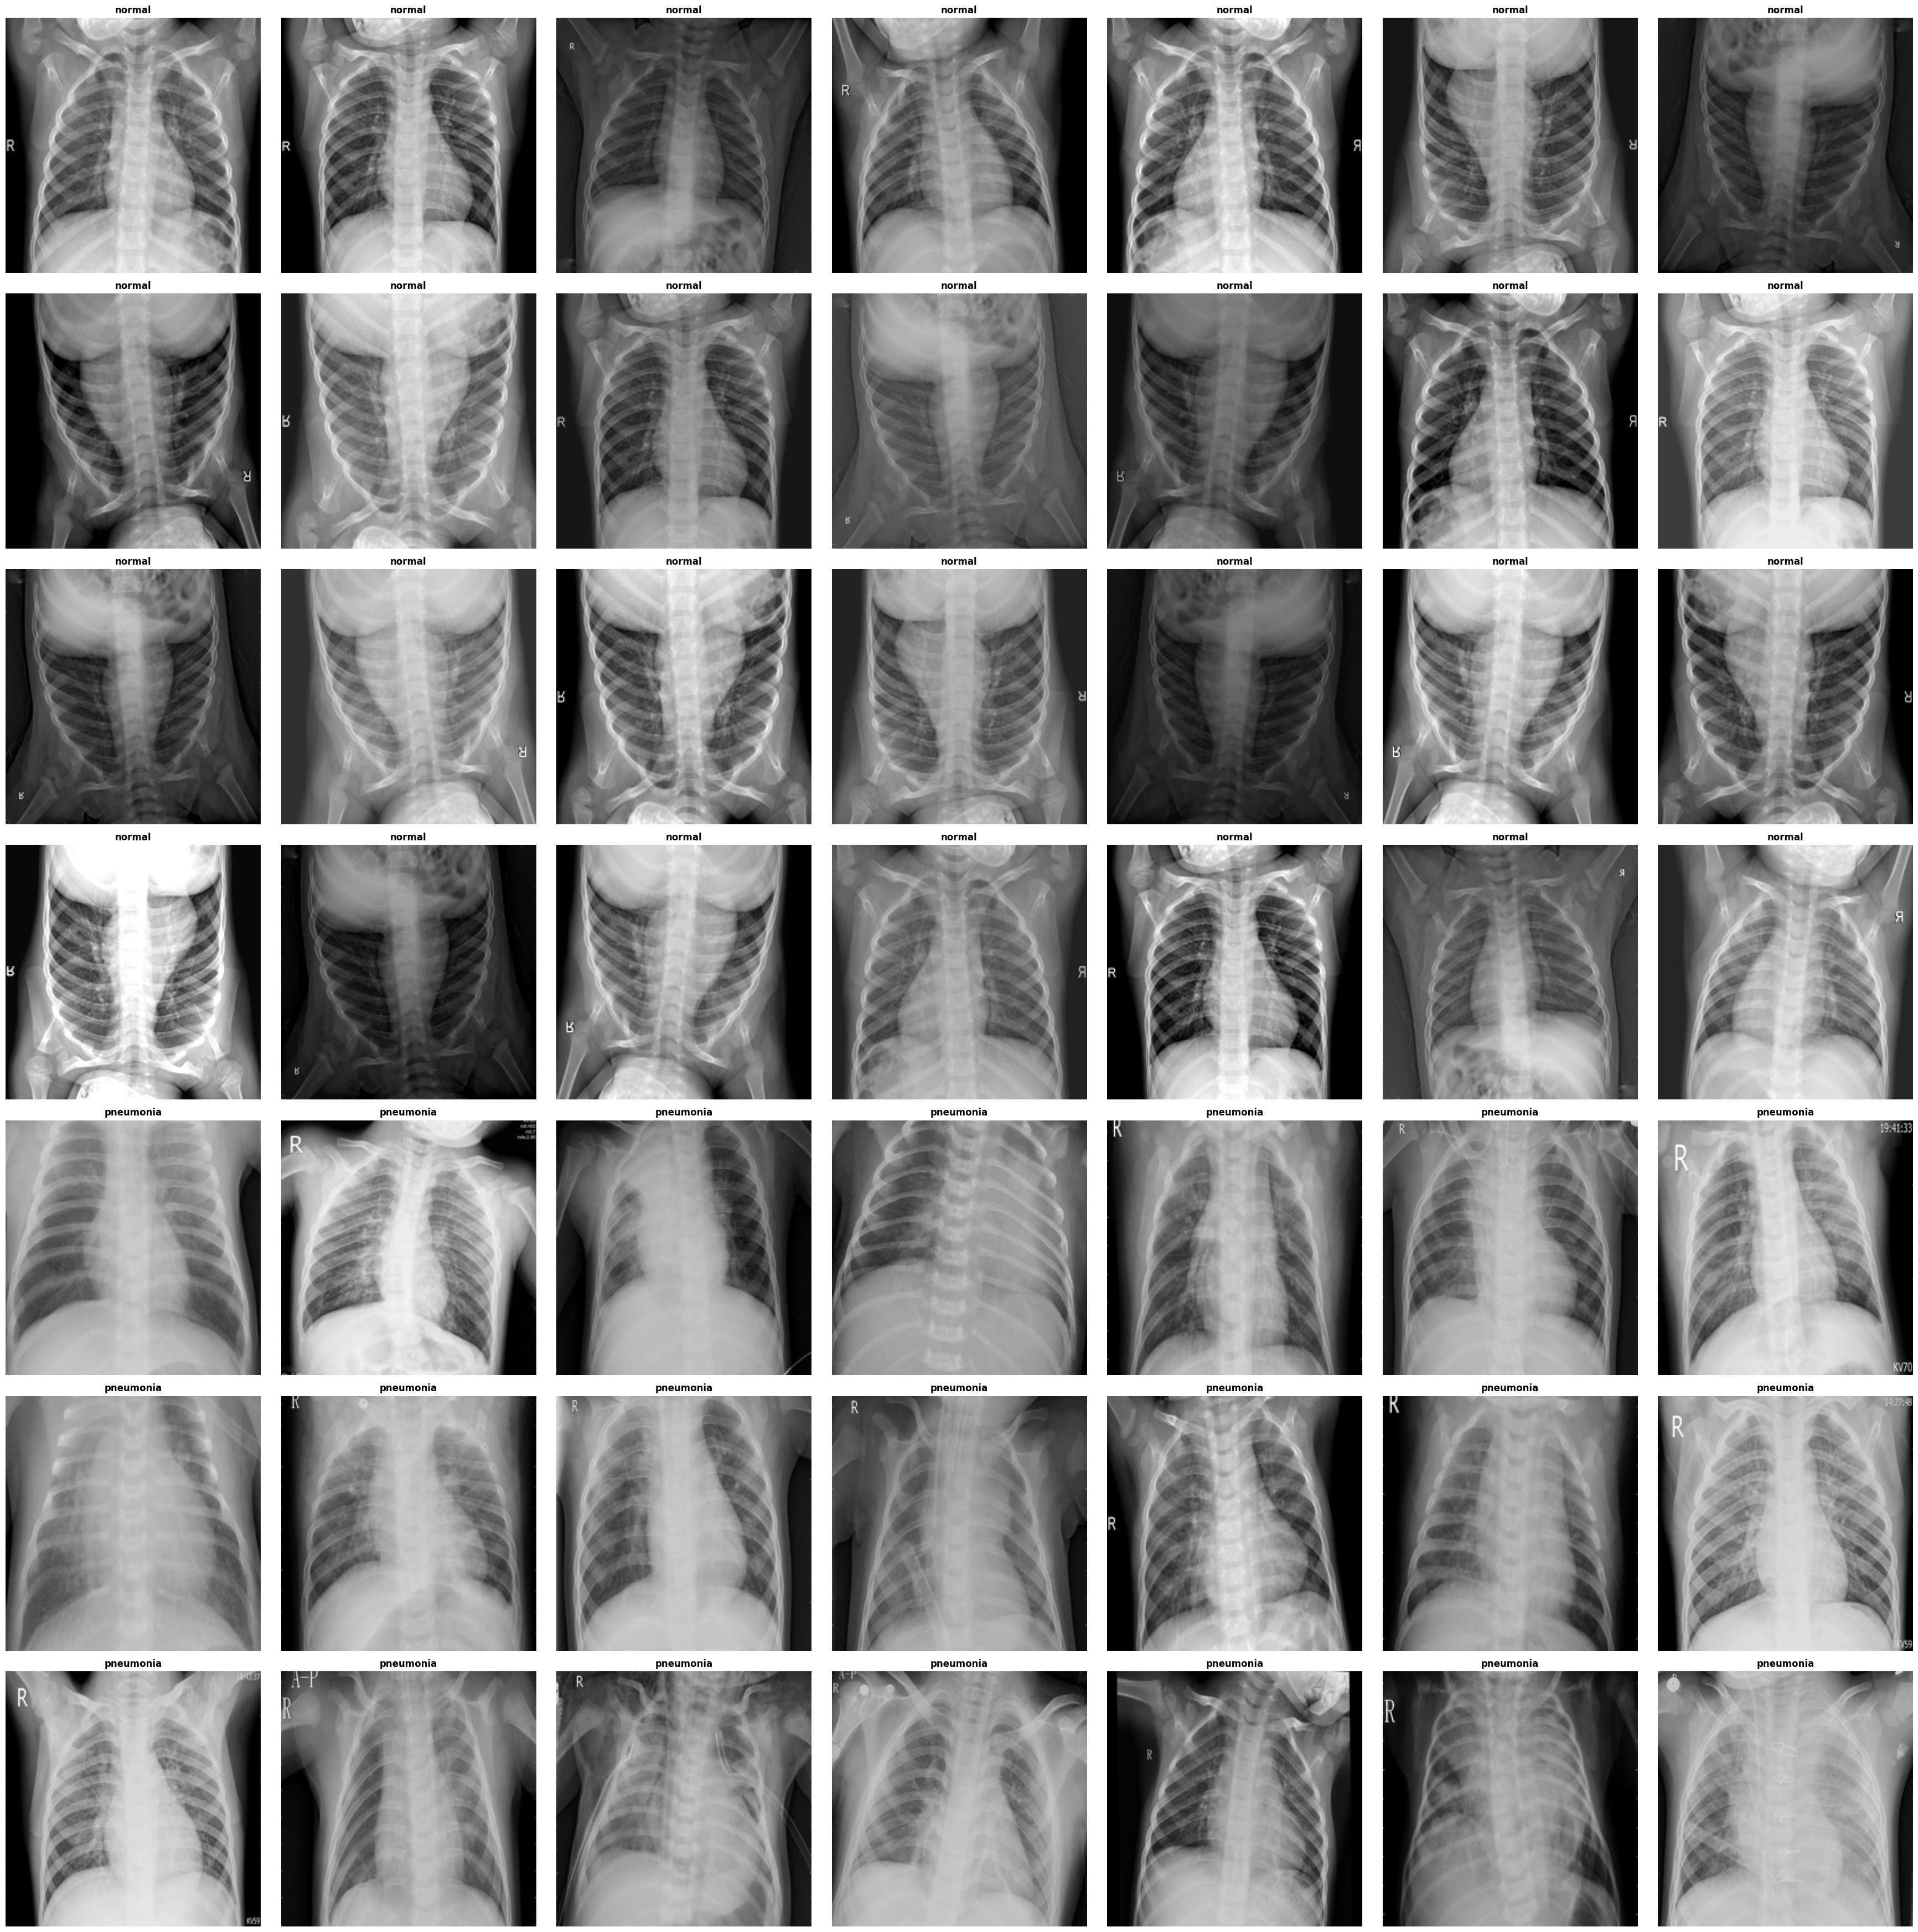

In [6]:
classes={0:"normal",1:"pneumonia"}
def show_images(images_patch, labels):
    """
    Display a grid of images with their corresponding labels.

    Parameters:
    - images_patch (list or array-like): A collection of image arrays to display.
    - labels (list or array-like): Labels corresponding to each image in `images_patch`.
    """

    # Calculate the number of images per row and column
    images_num = int(np.sqrt(len(images_patch)))

    # Create a grid of subplots with `images_num` rows and `images_num` columns
    fig, ax = plt.subplots(images_num, images_num, figsize=(images_num *5, images_num *5))

    count = 0  # Initialize a counter to keep track of the current image index

    # Loop over the rows of the subplot grid
    for i in range(images_num):
        # Loop over the columns of the subplot grid
        for j in range(images_num):
            if count < len(images_patch):
                # Display the image at the current index in the subplot
                # images_patch[count]=
                ax[i][j].imshow(images_patch[count])

                # Set the title of the subplot to the label of the current image
                ax[i][j].set_title(classes[int(labels[count])], fontweight='bold')

                # Hide the axis for the  subplot
                ax[i][j].set_axis_off()

                count += 1  # Increment the counter for the next image

#     # Set a title for the entire grid of images
#     fig.suptitle('Grid of Train Images', fontsize=30, fontweight='bold')

    # Adjust layout to prevent overlap and ensure proper spacing
    plt.tight_layout()

    # Display the grid of images
    plt.show()
plot=True
if plot:
   show_images(train_images_batch, train_labels_batch)

## model choosing 

In [6]:
image_shape=(224,224,3)
DenseNet121_ = DenseNet121(input_shape=image_shape, include_top=False, weights='imagenet')
ResNet50_ = ResNet50(input_shape=image_shape, include_top=False, weights='imagenet')

# Corrected spelling for `trainable`
DenseNet121_.trainable = False
ResNet50_.trainable = False


In [7]:
ResNet50_clf = Sequential([
    InputLayer(input_shape=image_shape),
    ResNet50_,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

DenseNet121_clf = Sequential([
    InputLayer(input_shape=image_shape),
    DenseNet121_,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])




/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [8]:
models_list=[ResNet50_clf,DenseNet121_clf]
print("*"*90)
for i in models_list:
  print("*"*90)
  print(i.summary())
  print("*"*90)
print("*"*90)

******************************************************************************************
******************************************************************************************


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

None
******************************************************************************************
******************************************************************************************


In [13]:
models_list_names=["ResNet50_clf","DenseNet121_clf"]
def train_and_evaluate_models(models_list, train_dataset, validation_dataset, epochs, batch_size, final_model, l_r,best_model_name="", patience=3):
    """
    Trains a list of models and evaluates their validation accuracy.
    ...
    """
    model_performance = {}
    length = len(models_list)
    
    for i, model in enumerate(models_list):
        print("*" * 90)
        if(final_model):
            string_me=best_model_name
        else:
            string_me=models_list_names[i]
        print(f"Training model: {string_me}   {i + 1}/{length}...")

        # Compile the model
        model.compile(Adam(learning_rate=l_r),
                      loss="binary_crossentropy",
                      metrics=["binary_accuracy"])

        # Set up EarlyStopping callback
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True,min_delta=0.006)

        # Train the model with EarlyStopping
        history = model.fit(
              x=train_dataset,                      # Input data for training
              y=None,                               # Labels (not required when using a generator)
             epochs=epochs,                        # Number of epochs to train the model
             batch_size=batch_size,                # Number of samples per gradient update
             validation_data=validation_dataset,   # Data on which to evaluate the loss and any model metrics at the end of each epoch
             validation_steps=None,                # Optional, number of steps to yield from validation generator before stopping
             callbacks=[early_stopping]           # List of callback functions to apply during training
)


        # Store the validation accuracy of the final epoch
        val_accuracy = history.history['val_binary_accuracy'][-1]
        model_performance[f"build_model_{i + 1}"] = val_accuracy
        print(f"Model {string_me} {i + 1} validation accuracy: {val_accuracy}")
        print("*" * 90)

        if not final_model:
            # Clear the session to free memory
            tf.keras.backend.clear_session()
            # Delete the model objects and force garbage collection
            del model
            gc.collect()
        else:
            # Return the best model if final_model is True
            return model, history

    # Find the best model based on validation accuracy
    best_model_name = max(model_performance, key=model_performance.get)
    best_model_val_accuracy = model_performance[best_model_name]

    print(f"The best model is {best_model_name} with a val accuracy of {best_model_val_accuracy}")

    return model_performance, best_model_name,history


In [10]:
epochs=5
model_performance, best_model_name,history=train_and_evaluate_models(models_list, train_dataset,test_dataset, epochs, 32, False,1e-4) 

******************************************************************************************
Training model: ResNet50_clf   1/2...
Epoch 1/5


I0000 00:00:1730663969.808018     494 service.cc:145] XLA service 0x7e12780020f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730663969.808069     494 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730663969.808074     494 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


      1/Unknown 15s 15s/step - binary_accuracy: 0.5400 - loss: 0.7502

I0000 00:00:1730663977.406754     494 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    163/Unknown 193s 1s/step - binary_accuracy: 0.5371 - loss: 0.7029

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


163/163 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - binary_accuracy: 0.5374 - loss: 0.7028 - val_binary_accuracy: 0.7526 - val_loss: 0.6424
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 819ms/step - binary_accuracy: 0.7233 - loss: 0.6208 - val_binary_accuracy: 0.7232 - val_loss: 0.6055
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 829ms/step - binary_accuracy: 0.7548 - loss: 0.5766 - val_binary_accuracy: 0.6747 - val_loss: 0.5968
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 825ms/step - binary_accuracy: 0.7618 - loss: 0.5429 - val_binary_accuracy: 0.7105 - val_loss: 0.5701
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 827ms/step - binary_accuracy: 0.7677 - loss: 0.5197 - val_binary_accuracy: 0.7309 - val_loss: 0.5516
Model ResNet50_clf 1 validation accuracy: 0.730867326259613
******************************************************************************************
******************************************************************************************
Training model: DenseNet121_clf   2/2...
Epoch

In [12]:
epochs=5
DenseNet121_clf, history=train_and_evaluate_models([DenseNet121_clf], train_dataset,test_dataset, epochs, 32, True,3e-4) 

******************************************************************************************
Training model:    1/1...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - binary_accuracy: 0.9266 - loss: 0.1891 - val_binary_accuracy: 0.8444 - val_loss: 0.3879
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 826ms/step - binary_accuracy: 0.9586 - loss: 0.1214 - val_binary_accuracy: 0.8571 - val_loss: 0.3761
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 820ms/step - binary_accuracy: 0.9599 - loss: 0.1050 - val_binary_accuracy: 0.8189 - val_loss: 0.4584
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 819ms/step - binary_accuracy: 0.9689 - loss: 0.0868 - val_binary_accuracy: 0.8074 - val_loss: 0.5085
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 818ms/step - binary_accuracy: 0.9739 - loss: 0.0791 - val_binary_accuracy: 0.8227 - val_loss: 0.4774
Model  1 validation accuracy: 0.8227040767669678
******************************************************************************************


In [13]:
DenseNet121_clf.save("last_dance_v1.keras")

In [16]:
# Define the image shape
image_shape = (224, 224, 3)  # Example shape for DenseNet121

# Create the DenseNet121 model without loading pre-trained weights
DenseNet121_ = DenseNet121(weights=None, include_top=False, input_shape=image_shape)
# ResNet50(weights=None, include_top=False, input_shape=image_shape)
# Function to initialize weights uniformly
def initialize_uniform_weights(model):
    for layer in model.layers:
        if hasattr(layer, 'kernel'):
            # Initialize weights uniformly between a specified range, e.g., -0.05 and 0.05
            uniform_weights = tf.random.uniform(shape=layer.kernel.shape, minval=-0.05, maxval=0.05)
            layer.kernel.assign(uniform_weights)

# Create the complete model
DenseNet121_clf = Sequential([
    InputLayer(input_shape=image_shape),
    DenseNet121_,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Set all layers to be trainable
DenseNet121_.trainable = True

# Initialize the weights of DenseNet121 uniformly
initialize_uniform_weights(DenseNet121_)



In [17]:
#train the best model
epochs=5
DenseNet121_clf, history=train_and_evaluate_models([DenseNet121_clf], train_dataset,test_dataset, epochs, 32, True,3e-4) 

******************************************************************************************
Training model:    1/1...
Epoch 1/5


I0000 00:00:1730667920.005187      79 service.cc:145] XLA service 0x77fe50004bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730667920.005244      79 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730667920.005250      79 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1730668030.565319      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    163/Unknown 1614s 9s/step - binary_accuracy: 0.8888 - loss: 0.2602

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


163/163 ━━━━━━━━━━━━━━━━━━━━ 1678s 9s/step - binary_accuracy: 0.8890 - loss: 0.2597 - val_binary_accuracy: 0.5000 - val_loss: 0.8846
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 857ms/step - binary_accuracy: 0.9714 - loss: 0.0861 - val_binary_accuracy: 0.5000 - val_loss: 5.8866
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 856ms/step - binary_accuracy: 0.9747 - loss: 0.0616 - val_binary_accuracy: 0.5128 - val_loss: 1.2930
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 856ms/step - binary_accuracy: 0.9849 - loss: 0.0464 - val_binary_accuracy: 0.5000 - val_loss: 5.6521
Model  1 validation accuracy: 0.5
******************************************************************************************


In [18]:
# Define the image shape
image_shape = (224, 224, 3)  # Example shape for DenseNet121

# Create the DenseNet121 model without loading pre-trained weights
ResNet50_ = ResNet50(weights=None, include_top=False, input_shape=image_shape)
# ResNet50(weights=None, include_top=False, input_shape=image_shape)
# Function to initialize weights uniformly
def initialize_uniform_weights(model):
    for layer in model.layers:
        if hasattr(layer, 'kernel'):
            # Initialize weights uniformly between a specified range, e.g., -0.05 and 0.05
            uniform_weights = tf.random.uniform(shape=layer.kernel.shape, minval=-0.05, maxval=0.05)
            layer.kernel.assign(uniform_weights)

# Create the complete model
ResNet50_clf = Sequential([
    InputLayer(input_shape=image_shape),
    ResNet50_,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Set all layers to be trainable
ResNet50_clf.trainable = True

# Initialize the weights of DenseNet121 uniformly
initialize_uniform_weights(ResNet50_)

#train the best model
epochs=5
ResNet50_clf, history=train_and_evaluate_models([ResNet50_clf], train_dataset,test_dataset, epochs, 32, True,1e-5) 

******************************************************************************************
Training model:    1/1...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - binary_accuracy: 0.7015 - loss: 0.6223 - val_binary_accuracy: 0.5000 - val_loss: 2.5327
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 867ms/step - binary_accuracy: 0.8777 - loss: 0.3038 - val_binary_accuracy: 0.5000 - val_loss: 6.1066
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 857ms/step - binary_accuracy: 0.9229 - loss: 0.2104 - val_binary_accuracy: 0.5000 - val_loss: 6.4093
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 855ms/step - binary_accuracy: 0.9374 - loss: 0.1609 - val_binary_accuracy: 0.5026 - val_loss: 2.7578
Model  1 validation accuracy: 0.5025510191917419
******************************************************************************************


In [35]:
# Define the image shape
image_shape = (224, 224, 3)

# Create the DenseNet121 model without loading pre-trained weights
DenseNet121_ = DenseNet121(weights="imagenet", include_top=False, input_shape=image_shape)
DenseNet121_.trainable = False


# Create the complete model with regularization
DenseNet121_clf = Sequential([
    InputLayer(input_shape=image_shape),
    DenseNet121_,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),  # L2 regularization on dense layer,
    BatchNormalization(),
    Dropout(0.5),  # Higher dropout rate to prevent overfitting
    Dense(1, activation='sigmoid')
])



# Define training parameters
epochs = 5
batch_size = 32
learning_rate = 3e-5
DenseNet121_clf, history=train_and_evaluate_models([DenseNet121_clf], train_dataset,test_dataset, epochs, batch_size, True,learning_rate) 

******************************************************************************************
Training model:    1/1...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - binary_accuracy: 0.5917 - loss: 0.8429 - val_binary_accuracy: 0.7666 - val_loss: 0.5138
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 135s 830ms/step - binary_accuracy: 0.8689 - loss: 0.3412 - val_binary_accuracy: 0.8418 - val_loss: 0.3888
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 818ms/step - binary_accuracy: 0.9057 - loss: 0.2637 - val_binary_accuracy: 0.8418 - val_loss: 0.3719
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 824ms/step - binary_accuracy: 0.9197 - loss: 0.2229 - val_binary_accuracy: 0.8214 - val_loss: 0.4089
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 824ms/step - binary_accuracy: 0.9348 - loss: 0.1946 - val_binary_accuracy: 0.8380 - val_loss: 0.3929
Model  1 validation accuracy: 0.8380101919174194
******************************************************************************************


In [36]:
# Define training parameters
epochs = 5
batch_size = 32
learning_rate = 1e-5
DenseNet121_clf, history=train_and_evaluate_models([DenseNet121_clf], train_dataset,test_dataset, epochs, batch_size, True,learning_rate) 

******************************************************************************************
Training model:    1/1...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - binary_accuracy: 0.9192 - loss: 0.2229 - val_binary_accuracy: 0.8291 - val_loss: 0.4039
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 972ms/step - binary_accuracy: 0.9336 - loss: 0.2053 - val_binary_accuracy: 0.8469 - val_loss: 0.3878
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 154s 944ms/step - binary_accuracy: 0.9378 - loss: 0.1831 - val_binary_accuracy: 0.8444 - val_loss: 0.3849
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 933ms/step - binary_accuracy: 0.9405 - loss: 0.1782 - val_binary_accuracy: 0.8457 - val_loss: 0.3825
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 938ms/step - binary_accuracy: 0.9375 - loss: 0.1810 - val_binary_accuracy: 0.8457 - val_loss: 0.3746
Model  1 validation accuracy: 0.8456632494926453
******************************************************************************************


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import InputLayer, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

# Define the image shape
image_shape = (224, 224, 3)

# Step 1: Load the DenseNet121 base model without the top layer
base_model = DenseNet121(weights=None, include_top=False, input_shape=image_shape)

# Step 2: Load CheXNet weights into the base model
# You need to specify that you want to exclude the top layer in the weight loading
base_model.load_weights('/kaggle/input/chexnet-weights/brucechou1983_CheXNet_Keras_0.3.0_weights.h5', by_name=True)

# Step 3: Create a new model by adding a new classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(128, activation='relu')(x)  # Fully connected layer
x = BatchNormalization()(x)  # Normalize activations
x = Dropout(0.5)(x)  # Dropout for regularization
predictions = Dense(1, activation='sigmoid')(x)  # Output layer for 14 classes

# Create the complete model
DenseNet121_clf = Model(inputs=base_model.input, outputs=predictions)

# Step 4: Compile the final model
learning_rate = 3e-5
DenseNet121_clf.compile(optimizer=Adam(learning_rate=learning_rate),
                         loss='binary_crossentropy',  # Use 'binary_crossentropy' or 'categorical_crossentropy' based on your labels
                         metrics=['accuracy'])

# Step 5: Define training parameters
epochs = 5
batch_size = 32

# Step 6: Train and evaluate the model
history = DenseNet121_clf.fit(train_dataset, 
                               validation_data=test_dataset, 
                               epochs=epochs, 
                               batch_size=batch_size)


Epoch 1/5


I0000 00:00:1730676790.277429      77 service.cc:145] XLA service 0x795eec0036b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730676790.277515      77 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730676790.277520      77 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1730676902.907811      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    163/Unknown 1550s 8s/step - accuracy: 0.7276 - loss: 0.5701

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


163/163 ━━━━━━━━━━━━━━━━━━━━ 1616s 9s/step - accuracy: 0.7280 - loss: 0.5694 - val_accuracy: 0.6485 - val_loss: 0.6552
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 946ms/step - accuracy: 0.8932 - loss: 0.2666 - val_accuracy: 0.5406 - val_loss: 0.6846
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9354 - loss: 0.1736 - val_accuracy: 0.5635 - val_loss: 1.1041
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9500 - loss: 0.1334 - val_accuracy: 0.7145 - val_loss: 0.7198
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9625 - loss: 0.0996 - val_accuracy: 0.8236 - val_loss: 0.4349


In [ ]:
def plot_accuracy( history, string="Validation"):
    """
    Plots the accuracy and loss for both training and validation over epochs.

    Parameters:
    - epoch (int): The total number of epochs.
    - history (History object): The history object returned by the model training process (e.g., from Keras).
    - string (str, optional): Custom label for the validation metrics. Defaults to "Validation".

    This function creates two subplots: one for accuracy and one for loss, comparing
    training and validation metrics over the number of epochs.
    """

    # Generate an array of epoch numbers (e.g., [1, 2, ..., epoch])
   

    # Extract the accuracy and loss data from the history object
    train_accuracy = history.history['accuracy']          # Training accuracy
    val_accuracy = history.history.get('val_accuracy')    # Validation accuracy (use .get() in case there's no validation)
    train_loss = history.history['loss']                  # Training loss
    val_loss = history.history.get('val_loss')            # Validation loss (use .get() for safety)
    epoch=len(train_accuracy)
    epochs = np.arange(1, epoch + 1)

    # Create a figure with two subplots (1 row, 2 columns)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Accuracy Plot
    ax[0].plot(epochs, train_accuracy, label="Train Accuracy", color="b", linestyle="--", linewidth=2, marker='o', alpha=0.7)
    if val_accuracy:
        ax[0].plot(epochs, val_accuracy, label=f"{string} Accuracy", color="g", linestyle=":", linewidth=2, marker='s', alpha=0.7)
    ax[0].set_title("Accuracy")
    ax[0].legend()
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].grid(True)  # Add a grid for better readability
    ax[0].set_ylim([0, 1])

    # Loss Plot
    ax[1].plot(epochs, train_loss, label="Train Loss", color="r", linestyle="--", linewidth=2, marker='o', alpha=0.7)
    if val_loss:
        ax[1].plot(epochs, val_loss, label=f"{string} Loss", color="m", linestyle=":", linewidth=2, marker='s', alpha=0.7)
    ax[1].set_title("Loss")
    ax[1].legend()
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].grid(True)  # Add a grid for better readability
    ax[1].set_ylim([0, max(val_loss)+1])

    # Adjust layout for better spacing between subplots
    plt.tight_layout()

    # Display the plots
    plt.show()
def plot_testing_confusion_heat_map(y_test_act, y_test_pred, str6=""):
    # Confusion matrix for testing data
    clf_matrix_test = confusion_matrix(y_test_act, y_test_pred, normalize='true') * 100
    clf_matrix_str_test = np.round(clf_matrix_test, 1).astype(str)

    size = 8
    plt.rcParams.update({'font.size': size, 'font.family': 'Times New Roman'})

    # Create a figure for the heatmap
    fig, ax_test = plt.subplots(figsize=(8, 5))

    # Plot for testing heatmap
    sns.heatmap(clf_matrix_test, annot=clf_matrix_str_test, annot_kws={'weight': "bold"}, fmt='s',
                cmap='YlGnBu', cbar=False, ax=ax_test)

    ax_test.set_xlabel('Predicted Label', size=size + 2, fontweight='bold')
    ax_test.set_ylabel('True Label', size=size + 2, fontweight='bold')
    ax_test.tick_params(axis='both', which='major', labelsize=size + 1)
    ax_test.set_xticklabels(ax_test.get_xticklabels(), fontweight='bold')
    ax_test.set_yticklabels(ax_test.get_yticklabels(), fontweight='bold')

    # Add a color bar for the heatmap
    cbar = fig.colorbar(ax_test.collections[0], ax=ax_test, location='right', pad=0.02, shrink=1)
    cbar.ax.tick_params(labelsize=size + 1)
    cbar.set_label('Accuracy (%)', size=size + 1, fontweight='bold')
    cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontweight='bold')

    # Add subplot title
    fig.text(0.4, 0.92, 'Confusion Matrix (Testing)', fontsize=size + 3, fontweight='bold', ha='center')

    plt.show()

In [ ]:
plot_accuracy( history, string="Validation")

## model testing

In [ ]:
# Make predictions
predictions = model.predict(test_dataset)
predicted_classes = np.argmax(predictions, axis=1)  # Get the predicted class indices

# Get true labels from the dataset
true_labels = []
for _, labels in test_dataset:
    true_labels.extend(labels.numpy())

# Convert true labels to a numpy array
true_labels = np.array(true_labels)


# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_classes)
print(f'Accuracy: {accuracy:.4f}')

# Calculate F1 score
f1 = f1_score(true_labels, predicted_classes, average='weighted') 
print(f'F1 Score: {f1:.4f}')

# Generate a classification report
report = classification_report(true_labels, predicted_classes, target_names=classes.values())
print(report)


In [ ]:
plot_testing_confusion_heat_map(true_labels, predicted_classes, str6="")

In [ ]:
model.save("chest_xray_model.h5")
model.save("chest_xray_model.keras")